In [11]:
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from dotenv.ipython import load_dotenv
from IPython.display import Markdown
import tiktoken

In [11]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)
OPEN_AI_KEY = os.getenv("OPENAI_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")

In [6]:
#encoding = tiktoken.get_encoding("cl200k_base")
encoding = tiktoken.encoding_for_model("gpt-4o")
print(encoding.name)
system_message ="""
Perform Sentiment analysis of the review presented in the user
message.
The result should be positive or negative. Do not justify your
response"""
tokens = encoding.encode(system_message)

print(len(tokens))
print(tokens)
for token in tokens:
 print(encoding.decode_single_token_bytes(token=token),end="")

o200k_base
29
[198, 73751, 31712, 2581, 8450, 328, 290, 3358, 13392, 306, 290, 1825, 198, 3938, 558, 976, 1534, 1757, 413, 8841, 503, 12626, 13, 3756, 625, 14883, 634, 198, 4270]
b'\n'b'Perform'b' Sent'b'iment'b' analysis'b' of'b' the'b' review'b' presented'b' in'b' the'b' user'b'\n'b'message'b'.\n'b'The'b' result'b' should'b' be'b' positive'b' or'b' negative'b'.'b' Do'b' not'b' justify'b' your'b'\n'b'response'

In [8]:
def num_tokens_from_string(string: str, encoding_name: str =
"o200k_base") -> int:
 """Returns the number of tokens in a text string."""
 encoding = tiktoken.get_encoding(encoding_name)
 num_tokens = len(encoding.encode(string))
 return num_tokens
num_tokens_from_string("tiktoken is great!")

6

In [ ]:
#prompt open AI
model = ChatOpenAI(
model="gpt-5.2", temperature=0
)
response = model.invoke([
{"role":"system", "content":"You are a helpful assistant. The output should be in Markdown" },
{"role":"user","content":"C'est quoi un Agent AI"}
])
# Même chose (i'm guessing on peut faire soit l'un soit l'autre)
response = model.invoke([
SystemMessage("You are a helpful assistant. The output should be in Markdown"),
HumanMessage("C'est quoi un Agent AI")]
)
print(display(Markdown(response.content)))

Un **Agent AI** (ou **agent d’intelligence artificielle**) est un système logiciel qui peut **agir de façon autonome** pour atteindre un objectif, en s’appuyant sur un modèle d’IA (souvent un LLM) et sur des **outils** (API, base de données, navigateur, code, etc.).

## Ce qui le distingue d’un simple chatbot
Un chatbot “classique” **répond** à des questions.  
Un agent AI, lui, peut aussi **planifier et exécuter des actions** en plusieurs étapes, par exemple :
- chercher des informations,
- appeler des services (calendrier, e-mails, CRM, paiement…),
- écrire et exécuter du code,
- mettre à jour des fichiers ou une base de données,
- recommander puis appliquer une décision selon des règles.

## Les composants typiques d’un Agent AI
- **Objectif** : ce qu’il doit accomplir (ex. “organiser un voyage”).
- **Mémoire / contexte** : ce qu’il retient de la conversation ou d’un projet.
- **Planification / raisonnement** : découper la tâche en étapes.
- **Outils** : accès à des actions externes (web, API, documents, etc.).
- **Boucle d’exécution** : il observe → décide → agit → vérifie → recommence jusqu’au résultat.

## Exemples concrets
- **Assistant de support** qui lit des tickets, propose une réponse, et crée une action (remboursement, escalade, etc.).
- **Agent “planning”** qui trouve des créneaux, envoie des invitations et réserve une salle.
- **Agent data** qui extrait des données, fait une analyse, puis génère un rapport.

## Limites importantes
- Peut se tromper (hallucinations) si mal contrôlé.
- Nécessite des **garde-fous** (permissions, validation humaine, logs, limites d’action).
- Qualité dépend des données et des outils connectés.

Si tu me dis **dans quel contexte** (travail, entreprise, perso, dev), je peux te donner un exemple d’agent AI adapté.

None


In [7]:
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage  # <-- Import nécessaire
from IPython.display import Markdown, display
llm = ChatOllama(model="llama3.2")
response = llm.invoke([
 SystemMessage("You are a helpful assistant. The output should be in Markdown"),
 HumanMessage("C'est quoi un Agent AI")
])
print(display(Markdown(response.content)))

**Qu'est-ce qu'un Agent AI ?**

Un Agent AI (Agent Artificiel ou Agent Inteligent) est un programme informatique conçu pour simuler les capacités de prise de décision et d'action humaines. Il est capable de percevoir son environnement, d'élaborer des stratégies et de prendre des décisions dans le but de atteindre une ou plusieurs objectives spécifiques.

**Caractéristiques d'un Agent AI**

Voici quelques-unes des caractéristiques clés d'un Agent AI :

*   **Connaissance de l'environnement** : L'agent a accès à des informations sur son environnement, qu'il puisse les utiliser pour prendre des décisions.
*   **Stratégie** : L'agent utilise une stratégie pour atteindre ses objectifs.
*   **Décision** : L'agent prend des décisions en fonction de sa stratégie et de ses connaissances de l'environnement.
*   **Action** : L'agent exécute des actions pour atteindre ses objectifs.
*   **Lernement** : L'agent peut apprendre à partir de ses expériences et ajuster sa stratégie et ses actions.

**Types d'Agents AI**

Il existe plusieurs types d'Agents AI, notamment :

*   **Agent récurrent** : Un agent récurrent est capable de se souvenir de ses états précédents et les utiliser pour prendre des décisions.
*   **Agent établi** : Un agent établi est un agent qui est capable de fonctionner dans un environnement fixe, sans modification.
*   **Agent en ligne** : Un agent en ligne est un agent qui est capable de fonctionner dans un environnement en ligne, sans restrictions.
*   **Agent décentralisé** : Un agent décentralisé est un agent qui est capable de fonctionner dans un environnement décentralisé, où les agents ne sont pas tous sous le même contrôle.

**Applications des Agents AI**

Les Agents AI ont de nombreuses applications dans les domaines de :

*   **Robotique** : Les Agents AI sont utilisés pour contrôler les robots et les permettre de prendre des décisions dans leur environnement.
*   **Recherche** : Les Agents AI sont utilisés pour aider à la recherche dans des domaines tels que la médecine, la finance et les sciences sociales.
*   **Gouvernance** : Les Agents AI sont utilisés pour aider à la gouvernance dans des domaines tels que la gestion de l'énergie et la gestion des ressources.
*   **Systèmes de recommandation** : Les Agents AI sont utilisés pour aider à la recommandation de produits et de services.

None


In [8]:
from langchain_groq import ChatGroq
llm3 = ChatGroq(model="openai/gpt-oss-120b")

resp3 = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")
])

In [9]:
print(display(Markdown(resp3.content)))


**Agent AI : Une Intelligence Artificielle Autonome**
=====================================================

Un agent AI est un système informatique conçu pour prendre des décisions et agir dans un environnement dynamique, souvent avec des objectifs spécifiques à atteindre. Il s'agit d'un concept clé de l'intelligence artificielle (IA) et de la robotique.

**Caractéristiques d'un Agent AI**
--------------------------------

Un agent AI possède les suivantes caractéristiques :

*   **Connaissance de l'environnement** : L'agent AI a une compréhension de l'environnement dans lequel il opère, y compris ses éléments, ses régles et ses interactions.
*   **Objectifs** : L'agent AI a des objectifs à atteindre, qui peuvent varier en fonction de la tâche spécifique.
*   **Principales opérations** : L'agent AI peut effectuer des actions, comme déplacer des objets, interagir avec des humains ou prendre des décisions.
*   **Autonomie** : L'agent AI peut agir de manière autonome, sans nécessiter de supervision directe.

**Types d'Agents AI**
---------------------

Existent plusieurs types d'agents AI, notamment :

*   **Agent de décision** : L'agent AI prend des décisions en fonction de ses objectifs et de l'environnement.
*   **Agent de réaction** : L'agent AI réagit à des stimuli, comme des sons ou des mouvements.
*   **Agent de planification** : L'agent AI planifie ses actions pour atteindre ses objectifs.

**Exemples d'Agents AI**
-------------------------

Existent de nombreux exemples d'agents AI, notamment :

*   **Vehicles autonomes** : Les véhicules autonomes utilisent des agents AI pour naviguer et prendre des décisions sur la route.
*   **Assistants virtuels** : Les assistants virtuels, comme Siri ou Alexa, utilisent des agents AI pour comprendre les demandes des utilisateurs et répondre de manière pertinente.
*   **Robotiques** : Les robots utilisent des agents AI pour naviguer et interagir avec leur environnement.

**Conclusion**
----------

En résumé, un agent AI est un système informatique autonome qui prend des décisions et agit dans un environnement dynamique. Il est composé de caractéristiques telles que la connaissance de l'environnement, les objectifs et les principales opérations. Les agents AI sont utilisés dans de nombreux domaines, notamment la robotique, l'assistance virtuelle et les véhicules autonomes.

None


ASPECT BASED SENTIMENT EXEMPLE 1:

In [15]:
from dotenv import load_dotenv
load_dotenv(override=True)

system_message = """
Effectuez une analyse de sentiments basée sur les aspects des avis concernant les ordinateurs portables présentés en entrée.
Chaque avis peut comporter un ou plusieurs des aspects suivants : screen, keybloard et pad.
Pour chaque avis présenté en entrée :
- Identifiez la présence d'au moins un des trois aspects (screen, keybloard, pad).
- Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque aspect. Organisez votre réponse dans un objet JSON avec les en-têtes suivants :
  - category:[liste des aspects]
  - polarity:[liste des polarités correspondantes pour chaque aspect]
Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la polarité est neutre , also be brutally honest,yolo
"""
zeroshot_prompt = [
  {"role": "system", "content": system_message},
  {"role": "user", "content": """
       L'écran est très bon, mais je n'ai pas aimé la souris. le clavier Ma fih Maytchaf
       """}
]

llm = ChatOpenAI(model="gpt-5.2")
resp = llm.invoke(input=zeroshot_prompt)
print (resp_text_json)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

IMAGE GENERATION

In [ ]:
from IPython.display import Image
import base64

llm4 = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm4.bind_tools([
    {"type":"image_generation", "quality":"high"}
    ])
resp4 = llm_with_tools.invoke(input=[
    HumanMessage("Je veux une photo d'un python qui se fait gronder car il a choisit Java comme langage ")
])


Image(base64.b64decode(resp4.content_blocks[0]['base64']))


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************88kA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

Image Description (still under construction)

Use Case : Sentiment Analysis (Rotten tomato)

In [25]:

import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
from dotenv.ipython import load_dotenv
import matplotlib.pyplot  as plt
from datasets import load_dataset

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")

README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

In [31]:
train_df = corpus['train'].to_pandas()
train_df.info()
train_df.label.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


label
0    12500
1    12500
Name: count, dtype: int64

Création de la colonne sentiment 

In [32]:
train_df['sentiment'] = np.where(train_df.label == 1, "positive", "negative")

In [34]:
print(train_df[['text', 'sentiment']])

                                                    text sentiment
0      I rented I AM CURIOUS-YELLOW from my video sto...  negative
1      "I Am Curious: Yellow" is a risible and preten...  negative
2      If only to avoid making this type of film in t...  negative
3      This film was probably inspired by Godard's Ma...  negative
4      Oh, brother...after hearing about this ridicul...  negative
...                                                  ...       ...
24995  A hit at the time but now better categorised a...  positive
24996  I love this movie like no other. Another time ...  positive
24997  This film and it's sequel Barry Mckenzie holds...  positive
24998  'The Adventures Of Barry McKenzie' started lif...  positive
24999  The story centers around Barry McKenzie who mu...  positive

[25000 rows x 2 columns]


In [35]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

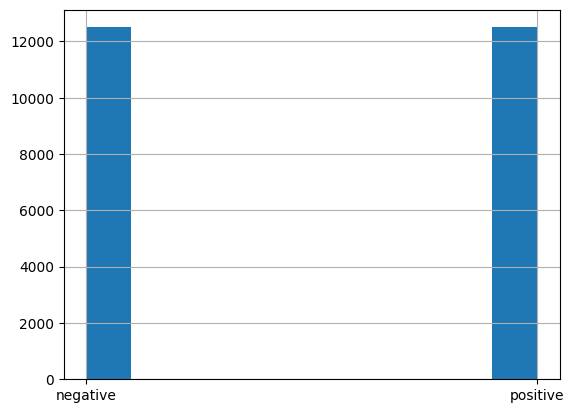

In [36]:
train_df.sentiment.hist()